# XAUUSD Smart Money Concepts (SMC) Validation Backtest - V2

## Proper Implementation with All Filters

**Key Changes from V1:**
1. HTF Trend Filter (30min swing structure)
2. Confirmation Candle Requirement  
3. Session Filter (London/NY only)
4. Quality Thresholds for Patterns
5. Realistic Entry Logic

**Approach:** Fix ONE pattern properly (Order Blocks), validate it works, then add others.

**Expected Realistic Win Rates:**
- Order Blocks with filters: 55-65%
- FVG with filters: 45-55%
- Sweeps with confirmation: 50-60%

In [198]:
# Cell 1: Imports and Configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# CONFIGURATION
# =============================================================================

# Timeframes
TIMEFRAMES = {'1min': 1, '5min': 5, '15min': 15, '30min': 30}
LTF = '15min'   # Lower timeframe for entries
HTF = '30min'   # Higher timeframe for trend

# Core Parameters
ATR_PERIOD = 14
SWING_LENGTH = 5
RR_TARGET = 2.0

# Quality Filters (NEW)
OB_MIN_DISPLACEMENT = 1.5      # ATR multiplier - OB must form after strong move
FVG_MIN_GAP = 0.5              # ATR multiplier - minimum gap size
SWEEP_MIN_WICK = 0.3           # ATR multiplier - minimum wick beyond level

# Session Filter (NEW)
TRADEABLE_SESSIONS = ['London', 'NewYork', 'KillZone']  # Only trade these sessions

# Session times (UTC)
SESSIONS = {
    'Asian': (0, 7),
    'London': (7, 16),
    'NewYork': (13, 22),
    'KillZone': (13, 17)  # London-NY Overlap - best session
}

# Backtest Settings
SAMPLE_SIZE = 3000
MAX_FUTURE_BARS = 100
DAYS_TO_ANALYZE = 1000  # 6 months

print("="*60)
print("SMC VALIDATION BACKTEST V2 - WITH PROPER FILTERS")
print("="*60)
print(f"\nKey Filters:")
print(f"  • HTF Trend: {HTF} swing structure")
print(f"  • Sessions: {TRADEABLE_SESSIONS}")
print(f"  • OB Displacement: >{OB_MIN_DISPLACEMENT}x ATR")
print(f"  • Confirmation candle required: YES")
print(f"\nTimeframes: LTF={LTF}, HTF={HTF}")

SMC VALIDATION BACKTEST V2 - WITH PROPER FILTERS

Key Filters:
  • HTF Trend: 30min swing structure
  • Sessions: ['London', 'NewYork', 'KillZone']
  • OB Displacement: >1.5x ATR
  • Confirmation candle required: YES

Timeframes: LTF=15min, HTF=30min


---
## Section 1: Data Preparation & Overview

In [199]:
# Cell 2: Load Data from Local CSV
DATA_FILE = '../data/snapshots/XAUUSD_COMPLETE.csv'

# How much data to use (in days) - full dataset is too slow for some algorithms
DAYS_TO_ANALYZE = 1300 # 6 months - good balance of speed vs sample size

def load_data_from_csv(filepath, last_n_days=None):
    """Load from CSV file"""
    print(f"Loading data from {filepath}...")
    df = pd.read_csv(filepath)
    
    # Convert timestamp to datetime and set as index
    df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
    df.set_index('timestamp', inplace=True)
    
    # Ensure numeric types
    for col in ['open', 'high', 'low', 'close', 'volume']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Remove timezone for easier resampling
    df.index = df.index.tz_localize(None)
    
    # Optionally limit to recent data for faster processing
    if last_n_days:
        cutoff = df.index.max() - timedelta(days=last_n_days)
        df = df[df.index >= cutoff]
        print(f"Using last {last_n_days} days of data")
    
    return df

# Load dataset (limited to recent data for performance)
df_1min = load_data_from_csv(DATA_FILE, last_n_days=DAYS_TO_ANALYZE)

print(f"Loaded {len(df_1min):,} 1-minute bars")
print(f"Date range: {df_1min.index.min()} to {df_1min.index.max()}")
print(f"Price range: ${df_1min['close'].min():.2f} to ${df_1min['close'].max():.2f}")
print(f"Index type: {type(df_1min.index)}")

Loading data from ../data/snapshots/XAUUSD_COMPLETE.csv...


Using last 1300 days of data
Loaded 716,138 1-minute bars
Date range: 2022-07-10 22:00:00 to 2026-01-30 21:59:00
Price range: $1615.08 to $5593.33
Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [200]:
# Cell 3: Aggregate to Multiple Timeframes
def aggregate_timeframe(df, minutes):
    """Aggregate 1-min data to higher timeframe"""
    return df.resample(f'{minutes}min').agg({
        'open': 'first', 'high': 'max', 'low': 'min', 'close': 'last', 'volume': 'sum'
    }).dropna()

# Create all timeframes
data = {'1min': df_1min.copy()}
for name, minutes in TIMEFRAMES.items():
    data[name] = aggregate_timeframe(df_1min, minutes)
    print(f"{name}: {len(data[name]):,} bars")

1min: 716,138 bars
5min: 143,356 bars
15min: 47,788 bars
30min: 23,899 bars


In [201]:
# Cell 4: Core Functions with HTF Trend Filter (NEW)

def calc_atr(df, period=14):
    """Calculate Average True Range - vectorized"""
    high, low, close = df['high'], df['low'], df['close'].shift(1)
    tr = np.maximum(high - low, np.maximum(abs(high - close), abs(low - close)))
    return tr.rolling(period).mean()

def detect_swing_points_vectorized(df, length=5):
    """Detect swing highs and lows using vectorized rolling operations"""
    roll_high = df['high'].rolling(window=2*length+1, center=True).max()
    roll_low = df['low'].rolling(window=2*length+1, center=True).min()
    
    swing_high_mask = df['high'] == roll_high
    swing_low_mask = df['low'] == roll_low
    
    swing_highs = [(ts, df.loc[ts, 'high']) for ts in df.index[swing_high_mask]]
    swing_lows = [(ts, df.loc[ts, 'low']) for ts in df.index[swing_low_mask]]
    
    return swing_highs, swing_lows

def get_session(ts):
    """Get session name for a timestamp (UTC)"""
    hour = ts.hour
    if 13 <= hour < 17: return 'KillZone'
    if 13 <= hour < 22: return 'NewYork'
    if 7 <= hour < 16: return 'London'
    if 0 <= hour < 7: return 'Asian'
    return 'Other'

def is_tradeable_session(ts):
    """Check if timestamp is in a tradeable session"""
    session = get_session(ts)
    return session in TRADEABLE_SESSIONS

# =============================================================================
# HTF TREND DETECTION (Less Strict Version)
# =============================================================================

def get_htf_trend_at_time(htf_df, swing_highs, swing_lows, timestamp, lookback=5):
    """
    Determine HTF trend at a specific time using swing structure.
    
    LESS STRICT VERSION:
    - BULLISH: Recent swing high > previous swing high OR recent swing low > previous swing low
    - BEARISH: Recent swing high < previous swing high OR recent swing low < previous swing low
    - NEUTRAL: Only if no clear direction
    """
    recent_highs = [(t, p) for t, p in swing_highs if t < timestamp][-lookback:]
    recent_lows = [(t, p) for t, p in swing_lows if t < timestamp][-lookback:]
    
    if len(recent_highs) < 2 or len(recent_lows) < 2:
        return 'NEUTRAL'
    
    # Check last two swings only (less strict)
    last_high = recent_highs[-1][1]
    prev_high = recent_highs[-2][1]
    last_low = recent_lows[-1][1]
    prev_low = recent_lows[-2][1]
    
    # Bullish: higher high OR higher low
    bullish_signals = (last_high > prev_high) + (last_low > prev_low)
    # Bearish: lower high OR lower low
    bearish_signals = (last_high < prev_high) + (last_low < prev_low)
    
    if bullish_signals >= 1 and bullish_signals > bearish_signals:
        return 'BULLISH'
    elif bearish_signals >= 1 and bearish_signals > bullish_signals:
        return 'BEARISH'
    else:
        return 'NEUTRAL'

# =============================================================================
# CONFIRMATION CANDLE (Less Strict Version)
# =============================================================================

def has_confirmation_candle(df, index, direction, min_body_ratio=0.3):
    """
    Check if the next candle confirms the setup direction.
    
    LESS STRICT VERSION:
    - For LONG: Just need a bullish candle (close > open)
    - For SHORT: Just need a bearish candle (close < open)
    - Body must be at least 30% of range (not a doji)
    
    Returns:
        (bool, int) - (has_confirmation, confirmation_bar_index)
    """
    # Look at next 3 candles for confirmation
    for offset in range(1, 4):
        if index + offset >= len(df):
            return False, None
        
        confirm = df.iloc[index + offset]
        
        body = abs(confirm['close'] - confirm['open'])
        full_range = confirm['high'] - confirm['low']
        
        if full_range == 0:
            continue
            
        body_ratio = body / full_range
        
        if direction == 'long':
            # Bullish confirmation: closes higher than open
            is_bullish = confirm['close'] > confirm['open']
            if is_bullish and body_ratio >= min_body_ratio:
                return True, index + offset
                
        else:  # short
            # Bearish confirmation: closes lower than open
            is_bearish = confirm['close'] < confirm['open']
            if is_bearish and body_ratio >= min_body_ratio:
                return True, index + offset
    
    return False, None

# Pre-compute indicators and swings for all timeframes
swing_points = {}

for tf in data:
    print(f"Processing {tf}...", end=" ")
    data[tf]['atr'] = calc_atr(data[tf], ATR_PERIOD)
    data[tf]['session'] = data[tf].index.map(get_session)
    data[tf]['tradeable'] = data[tf].index.map(is_tradeable_session)
    
    swing_points[tf] = detect_swing_points_vectorized(data[tf], SWING_LENGTH)
    print(f"Swings: {len(swing_points[tf][0])} highs, {len(swing_points[tf][1])} lows")

# Test HTF trend distribution
print("\n=== HTF Trend Distribution (30min) ===")
htf_highs, htf_lows = swing_points[HTF]
trend_counts = {'BULLISH': 0, 'BEARISH': 0, 'NEUTRAL': 0}
sample_times = data[LTF].index[::50]  # Sample every 50th bar
for ts in sample_times:
    trend = get_htf_trend_at_time(data[HTF], htf_highs, htf_lows, ts)
    trend_counts[trend] += 1
print(f"Sampled {len(sample_times)} timestamps:")
for trend, count in trend_counts.items():
    print(f"  {trend}: {count} ({count/len(sample_times)*100:.1f}%)")

print("\n✓ Core functions ready (with RELAXED filters).")

Processing 1min... Swings: 46713 highs, 47060 lows
Processing 5min... Swings: 9002 highs, 8994 lows
Processing 15min... Swings: 3042 highs, 2967 lows
Processing 30min... Swings: 1517 highs, 1500 lows

=== HTF Trend Distribution (30min) ===
Sampled 956 timestamps:
  BULLISH: 289 (30.2%)
  BEARISH: 276 (28.9%)
  NEUTRAL: 391 (40.9%)

✓ Core functions ready (with RELAXED filters).


In [202]:
# Cell 5: Data Overview Statistics
stats = []
for tf, df in data.items():
    daily_range = (df['high'] - df['low']).resample('D').mean().mean()
    stats.append({
        'Timeframe': tf,
        'Total Bars': len(df),
        'Date Range': f"{df.index.min().date()} to {df.index.max().date()}",
        'Avg Daily Range': f"${daily_range:.2f}",
        'Avg ATR': f"${df['atr'].mean():.2f}"
    })

pd.DataFrame(stats)

,Timeframe,Total Bars,Date Range,Avg Daily Range,Avg ATR
0,1min,716138,2022-07-10 to 2026-01-30,$0.70,$0.69
1,5min,143356,2022-07-10 to 2026-01-30,$1.73,$1.67
2,15min,47788,2022-07-10 to 2026-01-30,$3.22,$3.04
3,30min,23899,2022-07-10 to 2026-01-30,$4.81,$4.45


---
## Section 2A: Order Block Validation (PROPER IMPLEMENTATION)

**What makes a VALID Order Block:**
1. Strong displacement candle (> 1.5x ATR move)
2. Origin candle is opposite color (marks institutional activity)
3. HTF trend must align with OB direction
4. Must be in tradeable session (London/NY)
5. Need confirmation candle before entry

In [203]:
# Cell 6: Order Block Detection (WITH QUALITY FILTERS)

def detect_order_blocks_v2(df, atr_mult=1.5, require_opposite_candle=True):
    """
    Detect Order Blocks with proper quality filters.
    
    An Order Block is formed when:
    1. A displacement candle moves > atr_mult * ATR
    2. The previous candle (OB candle) is opposite color
    3. This marks where institutions likely placed orders
    
    Args:
        df: DataFrame with OHLC and ATR
        atr_mult: Minimum displacement as ATR multiple
        require_opposite_candle: OB candle must be opposite color to displacement
    
    Returns:
        DataFrame with detected Order Blocks
    """
    atr = df['atr'].values
    opens = df['open'].values
    closes = df['close'].values
    highs = df['high'].values
    lows = df['low'].values
    
    obs = []
    
    for i in range(2, len(df) - 1):
        if np.isnan(atr[i]): 
            continue
        
        displacement = atr[i] * atr_mult
        curr_move = closes[i] - opens[i]
        prev_move = closes[i-1] - opens[i-1]
        
        # Bullish OB: strong bullish displacement, previous candle was bearish
        if curr_move > displacement:
            if require_opposite_candle and prev_move >= 0:
                continue  # Previous candle must be bearish
            
            obs.append({
                'time': df.index[i-1],  # OB is the candle BEFORE displacement
                'ob_type': 'bullish',
                'high': highs[i-1],
                'low': lows[i-1],
                'displacement': curr_move,
                'displacement_atr': curr_move / atr[i],
                'atr': atr[i],
                'session': df.iloc[i-1]['session'] if 'session' in df.columns else 'unknown'
            })
        
        # Bearish OB: strong bearish displacement, previous candle was bullish
        elif curr_move < -displacement:
            if require_opposite_candle and prev_move <= 0:
                continue  # Previous candle must be bullish
            
            obs.append({
                'time': df.index[i-1],
                'ob_type': 'bearish',
                'high': highs[i-1],
                'low': lows[i-1],
                'displacement': abs(curr_move),
                'displacement_atr': abs(curr_move) / atr[i],
                'atr': atr[i],
                'session': df.iloc[i-1]['session'] if 'session' in df.columns else 'unknown'
            })
    
    return pd.DataFrame(obs)

# Detect OBs with quality filters
ob_results = {}
for tf in TIMEFRAMES:
    ob_results[tf] = detect_order_blocks_v2(data[tf], OB_MIN_DISPLACEMENT)
    
    if len(ob_results[tf]) > 0:
        # Show distribution by session
        session_counts = ob_results[tf]['session'].value_counts()
        tradeable = ob_results[tf][ob_results[tf]['session'].isin(TRADEABLE_SESSIONS)]
        print(f"{tf}: {len(ob_results[tf])} OBs detected, {len(tradeable)} in tradeable sessions")
    else:
        print(f"{tf}: 0 Order Blocks detected")

1min: 13387 OBs detected, 7131 in tradeable sessions
5min: 2087 OBs detected, 1141 in tradeable sessions
15min: 791 OBs detected, 495 in tradeable sessions
30min: 442 OBs detected, 311 in tradeable sessions


In [204]:
# Cell 7: Order Block Summary
ob_summary = []
for tf in TIMEFRAMES:
    if len(ob_results[tf]) > 0:
        df = ob_results[tf]
        bullish = len(df[df['ob_type'] == 'bullish'])
        bearish = len(df[df['ob_type'] == 'bearish'])
        avg_disp = df['displacement_atr'].mean()
        tradeable = len(df[df['session'].isin(TRADEABLE_SESSIONS)])
        ob_summary.append({
            'TF': tf, 
            'Total OBs': len(df), 
            'Bullish': bullish, 
            'Bearish': bearish,
            'Avg Displacement': f"{avg_disp:.1f}x ATR",
            'In Tradeable Sessions': tradeable
        })

print("=== Order Block Summary ===")
pd.DataFrame(ob_summary)

=== Order Block Summary ===


,TF,Total OBs,Bullish,Bearish,Avg Displacement,In Tradeable Sessions
0,1min,13387,6815,6572,1.9x ATR,7131
1,5min,2087,1005,1082,2.1x ATR,1141
2,15min,791,379,412,2.1x ATR,495
3,30min,442,203,239,2.1x ATR,311


In [205]:
# Cell 8: Order Block Strategy Backtest (WITH ALL FILTERS)

def backtest_ob_with_filters(
    ltf_df, 
    htf_df,
    obs, 
    htf_swing_highs,
    htf_swing_lows,
    rr_target=2.0, 
    max_bars=100,
    require_htf_alignment=True,
    require_session_filter=True,
    require_confirmation=True,
    sample_size=3000
):
    """
    Backtest Order Block strategy with proper filters.
    
    Filters applied:
    1. HTF Trend Alignment - only trade WITH the trend
    2. Session Filter - only trade London/NY sessions  
    3. Confirmation Candle - wait for confirmation before entry
    
    Entry Logic:
    - Price returns to OB zone
    - Wait for confirmation candle
    - Enter on close of confirmation candle
    
    Args:
        ltf_df: Lower timeframe DataFrame for entries
        htf_df: Higher timeframe DataFrame for trend
        obs: Order blocks DataFrame
        htf_swing_highs/lows: Pre-computed HTF swings for trend
        rr_target: Risk:Reward target
        require_htf_alignment: Filter by HTF trend
        require_session_filter: Filter by session
        require_confirmation: Require confirmation candle
    """
    if len(obs) == 0:
        return pd.DataFrame(), {}
    
    # Sample if needed
    if len(obs) > sample_size:
        obs_sample = obs.sample(n=sample_size, random_state=42)
    else:
        obs_sample = obs
    
    # Pre-convert to numpy for speed
    df_index = ltf_df.index
    df_highs = ltf_df['high'].values
    df_lows = ltf_df['low'].values
    df_closes = ltf_df['close'].values
    df_opens = ltf_df['open'].values
    df_atr = ltf_df['atr'].values
    
    trades = []
    filter_stats = {
        'total_obs': len(obs_sample),
        'filtered_htf': 0,
        'filtered_session': 0,
        'filtered_no_retest': 0,
        'filtered_no_confirm': 0,
        'trades_taken': 0
    }
    
    for _, ob in obs_sample.iterrows():
        ob_time = ob['time']
        ob_type = ob['ob_type']
        ob_high, ob_low = ob['high'], ob['low']
        ob_atr = ob['atr']
        
        # =====================================================
        # FILTER 1: HTF Trend Alignment
        # =====================================================
        if require_htf_alignment:
            htf_trend = get_htf_trend_at_time(htf_df, htf_swing_highs, htf_swing_lows, ob_time)
            
            # Bullish OB needs bullish HTF trend
            if ob_type == 'bullish' and htf_trend != 'BULLISH':
                filter_stats['filtered_htf'] += 1
                continue
            # Bearish OB needs bearish HTF trend
            if ob_type == 'bearish' and htf_trend != 'BEARISH':
                filter_stats['filtered_htf'] += 1
                continue
        
        # =====================================================
        # FILTER 2: Session Filter
        # =====================================================
        if require_session_filter:
            if ob['session'] not in TRADEABLE_SESSIONS:
                filter_stats['filtered_session'] += 1
                continue
        
        # =====================================================
        # Find where price returns to OB zone
        # =====================================================
        try:
            mask = df_index > ob_time
            if not mask.any():
                continue
            start_idx = mask.argmax()
        except:
            continue
        
        end_idx = min(start_idx + max_bars, len(ltf_df))
        if end_idx <= start_idx + 5:
            continue
        
        # Look for price entering OB zone
        entry_found = False
        entry_idx = None
        
        for i in range(start_idx, end_idx):
            if ob_type == 'bullish':
                # Price dips into bullish OB zone
                if df_lows[i] <= ob_high and df_closes[i] >= ob_low:
                    entry_found = True
                    entry_idx = i
                    break
            else:  # bearish
                # Price pushes into bearish OB zone
                if df_highs[i] >= ob_low and df_closes[i] <= ob_high:
                    entry_found = True
                    entry_idx = i
                    break
        
        if not entry_found:
            filter_stats['filtered_no_retest'] += 1
            continue
        
        # =====================================================
        # FILTER 3: Confirmation Candle
        # =====================================================
        direction = 'long' if ob_type == 'bullish' else 'short'
        
        if require_confirmation:
            has_confirm, confirm_idx = has_confirmation_candle(ltf_df, entry_idx, direction)
            if not has_confirm:
                filter_stats['filtered_no_confirm'] += 1
                continue
            entry_idx = confirm_idx  # Enter on confirmation candle
        
        # =====================================================
        # Execute Trade
        # =====================================================
        entry_price = df_closes[entry_idx]
        atr_at_entry = df_atr[entry_idx] if not np.isnan(df_atr[entry_idx]) else ob_atr
        
        if ob_type == 'bullish':
            stop = ob_low - 0.5 * atr_at_entry
            risk = entry_price - stop
            if risk <= 0:
                continue
            target = entry_price + risk * rr_target
            
            # Check outcome
            future_highs = df_highs[entry_idx:end_idx]
            future_lows = df_lows[entry_idx:end_idx]
            
            # Find which happens first
            target_bars = np.where(future_highs >= target)[0]
            stop_bars = np.where(future_lows <= stop)[0]
            
            target_hit = len(target_bars) > 0
            stop_hit = len(stop_bars) > 0
            
            if target_hit and stop_hit:
                # Both hit - check which was first
                result = 'win' if target_bars[0] < stop_bars[0] else 'loss'
            elif target_hit:
                result = 'win'
            elif stop_hit:
                result = 'loss'
            else:
                result = 'open'
                
        else:  # bearish
            stop = ob_high + 0.5 * atr_at_entry
            risk = stop - entry_price
            if risk <= 0:
                continue
            target = entry_price - risk * rr_target
            
            future_highs = df_highs[entry_idx:end_idx]
            future_lows = df_lows[entry_idx:end_idx]
            
            target_bars = np.where(future_lows <= target)[0]
            stop_bars = np.where(future_highs >= stop)[0]
            
            target_hit = len(target_bars) > 0
            stop_hit = len(stop_bars) > 0
            
            if target_hit and stop_hit:
                result = 'win' if target_bars[0] < stop_bars[0] else 'loss'
            elif target_hit:
                result = 'win'
            elif stop_hit:
                result = 'loss'
            else:
                result = 'open'
        
        filter_stats['trades_taken'] += 1
        trades.append({
            'time': ob_time,
            'ob_type': ob_type,
            'direction': direction,
            'entry': entry_price,
            'stop': stop,
            'target': target,
            'risk': risk,
            'result': result,
            'session': ob['session']
        })
    
    return pd.DataFrame(trades), filter_stats

# =============================================================================
# Run Backtest with Different Filter Combinations
# =============================================================================

print("="*60)
print("ORDER BLOCK BACKTEST - FILTER COMPARISON")
print("="*60)

# Get HTF swing points
htf_highs, htf_lows = swing_points[HTF]

# Test different filter combinations
filter_configs = [
    {'name': 'NO FILTERS (Baseline)', 'htf': False, 'session': False, 'confirm': False},
    {'name': 'HTF Only', 'htf': True, 'session': False, 'confirm': False},
    {'name': 'Session Only', 'htf': False, 'session': True, 'confirm': False},
    {'name': 'Confirmation Only', 'htf': False, 'session': False, 'confirm': True},
    {'name': 'HTF + Session', 'htf': True, 'session': True, 'confirm': False},
    {'name': 'ALL FILTERS', 'htf': True, 'session': True, 'confirm': True},
]

comparison_results = []

for config in filter_configs:
    trades, stats = backtest_ob_with_filters(
        ltf_df=data[LTF],
        htf_df=data[HTF],
        obs=ob_results[LTF],
        htf_swing_highs=htf_highs,
        htf_swing_lows=htf_lows,
        rr_target=RR_TARGET,
        require_htf_alignment=config['htf'],
        require_session_filter=config['session'],
        require_confirmation=config['confirm']
    )
    
    if len(trades) > 0 and 'result' in trades.columns:
        closed = trades[trades['result'].isin(['win', 'loss'])]
        if len(closed) > 0:
            wins = (closed['result'] == 'win').sum()
            losses = len(closed) - wins
            win_rate = wins / len(closed) * 100
            
            comparison_results.append({
                'Filter Config': config['name'],
                'Trades': len(closed),
                'Wins': wins,
                'Losses': losses,
                'Win Rate': f"{win_rate:.1f}%",
                'Filtered Out': stats['total_obs'] - stats['trades_taken']
            })

print("\n=== Filter Comparison Results ===")
comparison_df = pd.DataFrame(comparison_results)
print(comparison_df.to_string(index=False))

ORDER BLOCK BACKTEST - FILTER COMPARISON



=== Filter Comparison Results ===
        Filter Config  Trades  Wins  Losses Win Rate  Filtered Out
NO FILTERS (Baseline)     735   216     519    29.4%             6
             HTF Only     211    67     144    31.8%           566
         Session Only     445   139     306    31.2%           300
    Confirmation Only     462   141     321    30.5%           240
        HTF + Session     123    39      84    31.7%           655
          ALL FILTERS      75    22      53    29.3%           696


In [206]:
# Cell 10B: IMPROVED Order Block Strategy - Additional Filters
# This cell requires running cells 1-8 first to have data, swing_results, and ob_results

def backtest_ob_improved(
    ltf_df, 
    htf_df,
    obs, 
    htf_swing_highs,
    htf_swing_lows,
    rr_target=2.0, 
    max_bars=100,
    # Standard filters
    require_htf_alignment=True,
    require_session_filter=True,
    # NEW improved filters
    require_fresh_ob=True,          # Only trade OBs not previously tested
    require_rejection_wick=False,   # Require wick rejection on retest
    use_mitigation_entry=False,     # Enter at 50% of OB instead of touch
    premium_discount_filter=False,  # Only long in discount, short in premium
    max_retest_bars=50,             # OB must be retested within N bars
    sample_size=3000
):
    """
    Improved Order Block strategy with additional filters.
    
    NEW Filters:
    1. Fresh OB - only trade OBs that haven't been tested before
    2. Rejection Wick - require price rejection on retest
    3. Mitigation Entry - enter at 50% of OB body
    4. Premium/Discount - only long in discount zone
    5. Time Decay - OB must be retested within max_retest_bars
    """
    if len(obs) == 0:
        return pd.DataFrame(), {}
    
    # Sample if needed
    if len(obs) > sample_size:
        obs_sample = obs.sample(n=sample_size, random_state=42)
    else:
        obs_sample = obs
    
    # Pre-convert to numpy for speed
    df_index = ltf_df.index
    df_highs = ltf_df['high'].values
    df_lows = ltf_df['low'].values
    df_closes = ltf_df['close'].values
    df_opens = ltf_df['open'].values
    
    # Calculate swing range for premium/discount
    swing_range_high = ltf_df['high'].rolling(50).max().values
    swing_range_low = ltf_df['low'].rolling(50).min().values
    
    trades = []
    filter_stats = {
        'total_obs': len(obs_sample),
        'filtered_htf': 0,
        'filtered_session': 0,
        'filtered_not_fresh': 0,
        'filtered_no_retest': 0,
        'filtered_time_decay': 0,
        'filtered_premium_discount': 0,
        'filtered_no_rejection': 0,
        'trades_taken': 0
    }
    
    # Track tested OB levels to check freshness
    tested_ob_levels = set()
    
    for _, ob in obs_sample.iterrows():
        ob_time = ob['time']
        ob_type = ob['ob_type']
        ob_high, ob_low = ob['high'], ob['low']
        ob_mid = (ob_high + ob_low) / 2  # Mitigation level
        
        # Get start index
        try:
            start_idx = df_index.get_loc(ob_time)
        except:
            continue
            
        if start_idx + 5 >= len(ltf_df):
            continue
            
        # 1. HTF Alignment Filter
        if require_htf_alignment:
            htf_trend = get_htf_trend_at_time(htf_df, htf_swing_highs, htf_swing_lows, ob_time)
            if ob_type == 'bullish' and htf_trend != 'BULLISH':
                filter_stats['filtered_htf'] += 1
                continue
            if ob_type == 'bearish' and htf_trend != 'BEARISH':
                filter_stats['filtered_htf'] += 1
                continue
        
        # 2. Session Filter
        if require_session_filter:
            session = get_session(ob_time)
            if session not in TRADEABLE_SESSIONS:
                filter_stats['filtered_session'] += 1
                continue
        
        # 3. Fresh OB Filter - check if this level was already tested
        if require_fresh_ob:
            ob_level_key = round(ob_mid, 1)  # Round to 0.1 for grouping
            if ob_level_key in tested_ob_levels:
                filter_stats['filtered_not_fresh'] += 1
                continue
        
        # 4. Premium/Discount Filter
        if premium_discount_filter and not np.isnan(swing_range_high[start_idx]):
            equilibrium = (swing_range_high[start_idx] + swing_range_low[start_idx]) / 2
            if ob_type == 'bullish' and ob_mid > equilibrium:  # Want discount for longs
                filter_stats['filtered_premium_discount'] += 1
                continue
            if ob_type == 'bearish' and ob_mid < equilibrium:  # Want premium for shorts
                filter_stats['filtered_premium_discount'] += 1
                continue
        
        # Look for retest within max_retest_bars
        entry_idx = None
        entry_price = None
        j = start_idx
        
        for j in range(start_idx + 1, min(start_idx + max_retest_bars + 1, len(ltf_df))):
            low, high = df_lows[j], df_highs[j]
            close, open_p = df_closes[j], df_opens[j]
            
            # Determine entry level (touch or mitigation)
            if use_mitigation_entry:
                entry_level = ob_mid
            else:
                entry_level = ob_high if ob_type == 'bullish' else ob_low
            
            # Check for retest
            retest_hit = False
            if ob_type == 'bullish' and low <= entry_level:
                retest_hit = True
            elif ob_type == 'bearish' and high >= entry_level:
                retest_hit = True
            
            if retest_hit:
                # 5. Rejection Wick Filter
                if require_rejection_wick:
                    body = abs(close - open_p)
                    full_range = high - low
                    if full_range == 0:
                        continue
                    
                    if ob_type == 'bullish':
                        lower_wick = min(open_p, close) - low
                        if lower_wick < body * 0.5:  # Need wick > 50% of body
                            filter_stats['filtered_no_rejection'] += 1
                            continue
                    else:
                        upper_wick = high - max(open_p, close)
                        if upper_wick < body * 0.5:
                            filter_stats['filtered_no_rejection'] += 1
                            continue
                
                # Mark this level as tested
                if require_fresh_ob:
                    tested_ob_levels.add(ob_level_key)
                
                entry_idx = j
                entry_price = close
                break
        
        # Check if retest happened within time limit
        if entry_idx is None:
            if j >= start_idx + max_retest_bars:
                filter_stats['filtered_time_decay'] += 1
            else:
                filter_stats['filtered_no_retest'] += 1
            continue
        
        # Calculate SL/TP
        if ob_type == 'bullish':
            stop_loss = ob_low - 0.5  # Small buffer
            risk = entry_price - stop_loss
            take_profit = entry_price + (risk * rr_target)
            trade_type = 'long'
        else:
            stop_loss = ob_high + 0.5
            risk = stop_loss - entry_price  
            take_profit = entry_price - (risk * rr_target)
            trade_type = 'short'
        
        # Simulate trade outcome
        result = 'open'
        for k in range(entry_idx + 1, min(entry_idx + max_bars + 1, len(ltf_df))):
            h, l = df_highs[k], df_lows[k]
            
            if trade_type == 'long':
                if l <= stop_loss:
                    result = 'loss'
                    break
                if h >= take_profit:
                    result = 'win'
                    break
            else:
                if h >= stop_loss:
                    result = 'loss'
                    break
                if l <= take_profit:
                    result = 'win'
                    break
        
        if result != 'open':
            filter_stats['trades_taken'] += 1
            trades.append({
                'time': ob_time, 
                'type': trade_type, 
                'result': result,
                'entry_price': entry_price
            })
    
    return pd.DataFrame(trades), filter_stats


# Test improved filters
print("=" * 70)
print("IMPROVED ORDER BLOCK FILTERS TEST")
print("=" * 70)

# Get required data - use existing variables from earlier cells
ltf = LTF  # '15min' from config
htf = HTF  # '30min' from config
ltf_df = data[ltf].copy()
htf_df = data[htf].copy()

# Use existing swing points from cell 4
htf_highs = swing_results[htf]['highs']
htf_lows = swing_results[htf]['lows']

# Use existing OBs from cell 8
obs = ob_results[ltf]

print(f"Testing with {len(obs)} Order Blocks on {len(ltf_df)} bars ({len(ltf_df)/96:.0f} days)")
print()

# Test different improved filter combinations
test_configs = [
    {"name": "BASE (HTF+Session)", "htf": True, "session": True, "fresh": False, "reject": False, "mitig": False, "pd": False},
    {"name": "+ Fresh OB Only", "htf": True, "session": True, "fresh": True, "reject": False, "mitig": False, "pd": False},
    {"name": "+ Premium/Discount", "htf": True, "session": True, "fresh": False, "reject": False, "mitig": False, "pd": True},
    {"name": "+ Mitigation Entry", "htf": True, "session": True, "fresh": False, "reject": False, "mitig": True, "pd": False},
    {"name": "+ Rejection Wick", "htf": True, "session": True, "fresh": False, "reject": True, "mitig": False, "pd": False},
    {"name": "Fresh + P/D", "htf": True, "session": True, "fresh": True, "reject": False, "mitig": False, "pd": True},
    {"name": "Fresh + Mitig", "htf": True, "session": True, "fresh": True, "reject": False, "mitig": True, "pd": False},
    {"name": "ALL IMPROVED", "htf": True, "session": True, "fresh": True, "reject": False, "mitig": True, "pd": True},
]

results_improved = []

for config in test_configs:
    trades_df, stats = backtest_ob_improved(
        ltf_df, htf_df, obs, htf_highs, htf_lows,
        rr_target=2.0,
        max_bars=100,
        require_htf_alignment=config['htf'],
        require_session_filter=config['session'],
        require_fresh_ob=config['fresh'],
        require_rejection_wick=config['reject'],
        use_mitigation_entry=config['mitig'],
        premium_discount_filter=config['pd'],
        max_retest_bars=50
    )
    
    if len(trades_df) > 0:
        wins = len(trades_df[trades_df['result'] == 'win'])
        losses = len(trades_df[trades_df['result'] == 'loss'])
        total = wins + losses
        win_rate = (wins / total * 100) if total > 0 else 0
    else:
        wins, losses, total, win_rate = 0, 0, 0, 0
    
    results_improved.append({
        'Config': config['name'],
        'Trades': total,
        'Wins': wins,
        'Losses': losses,
        'Win%': f"{win_rate:.1f}%"
    })
    
    print(f"{config['name']:25} | Trades: {total:4} | Win Rate: {win_rate:5.1f}%")

print()
print("Filter breakdown for last config:")
for k, v in stats.items():
    print(f"  {k}: {v}")

# Summary table
print("\n" + "=" * 70)
print("SUMMARY - Comparing to ~30% baseline:")
results_df = pd.DataFrame(results_improved)
print(results_df.to_string(index=False))


IMPROVED ORDER BLOCK FILTERS TEST


NameError: name 'swing_results' is not defined

---
## Section 2B: Fair Value Gap Validation (PROPER IMPLEMENTATION)

**What makes a VALID FVG:**
1. Gap must be > 0.5x ATR (not tiny noise gaps)
2. Must form AFTER strong displacement move  
3. Entry on RETURN to FVG zone (not on formation)
4. HTF trend must align
5. Must be in tradeable session

In [ ]:
# Cell 9: FVG Detection (WITH QUALITY FILTERS)

def detect_fvgs_v2(df, min_gap_mult=0.5, require_displacement=True, displacement_mult=1.0):
    """
    Detect Fair Value Gaps with quality filters.
    
    A quality FVG:
    1. Gap between candle 0 high and candle 2 low (bullish) or vice versa
    2. Gap size must be >= min_gap_mult * ATR
    3. Should form after a displacement move (strong momentum)
    
    Args:
        df: DataFrame with OHLC and ATR
        min_gap_mult: Minimum gap size as ATR multiple
        require_displacement: Only count FVGs after strong move
        displacement_mult: ATR multiple for displacement check
    """
    fvgs = []
    
    for i in range(3, len(df)):
        atr = df['atr'].iloc[i]
        if pd.isna(atr): 
            continue
        
        min_gap = atr * min_gap_mult
        c0 = df.iloc[i-2]  # First candle
        c1 = df.iloc[i-1]  # Middle candle (the impulse)
        c2 = df.iloc[i]    # Third candle
        
        # Check for displacement (strong middle candle move)
        middle_move = abs(c1['close'] - c1['open'])
        has_displacement = middle_move >= atr * displacement_mult if require_displacement else True
        
        # Bullish FVG: gap between candle 0 high and candle 2 low
        if c2['low'] > c0['high'] and has_displacement:
            gap_size = c2['low'] - c0['high']
            if gap_size >= min_gap:
                fvgs.append({
                    'time': df.index[i],
                    'fvg_type': 'bullish',
                    'high': c2['low'],      # Top of gap
                    'low': c0['high'],       # Bottom of gap
                    'ce': (c2['low'] + c0['high']) / 2,  # 50% level
                    'gap_size': gap_size,
                    'gap_atr': gap_size / atr,
                    'displacement': middle_move,
                    'atr': atr,
                    'session': df.iloc[i]['session'] if 'session' in df.columns else 'unknown'
                })
        
        # Bearish FVG: gap between candle 0 low and candle 2 high
        if c2['high'] < c0['low'] and has_displacement:
            gap_size = c0['low'] - c2['high']
            if gap_size >= min_gap:
                fvgs.append({
                    'time': df.index[i],
                    'fvg_type': 'bearish',
                    'high': c0['low'],       # Top of gap
                    'low': c2['high'],        # Bottom of gap
                    'ce': (c0['low'] + c2['high']) / 2,
                    'gap_size': gap_size,
                    'gap_atr': gap_size / atr,
                    'displacement': middle_move,
                    'atr': atr,
                    'session': df.iloc[i]['session'] if 'session' in df.columns else 'unknown'
                })
    
    return pd.DataFrame(fvgs)

# Detect FVGs with quality filters
fvg_results = {}
for tf in TIMEFRAMES:
    fvg_results[tf] = detect_fvgs_v2(data[tf], FVG_MIN_GAP, require_displacement=True)
    
    if len(fvg_results[tf]) > 0:
        tradeable = fvg_results[tf][fvg_results[tf]['session'].isin(TRADEABLE_SESSIONS)]
        avg_gap = fvg_results[tf]['gap_atr'].mean()
        print(f"{tf}: {len(fvg_results[tf])} FVGs detected (avg {avg_gap:.1f}x ATR), {len(tradeable)} in tradeable sessions")
    else:
        print(f"{tf}: 0 FVGs detected")

1min: 45198 FVGs detected (avg 1.0x ATR), 25618 in tradeable sessions
5min: 6347 FVGs detected (avg 1.0x ATR), 3685 in tradeable sessions
15min: 1995 FVGs detected (avg 1.1x ATR), 1160 in tradeable sessions
30min: 1011 FVGs detected (avg 1.1x ATR), 649 in tradeable sessions


In [ ]:
# Cell 10: FVG Fill Behavior Tracking (OPTIMIZED - Summary only)
# Note: Detailed fill tracking skipped for speed. Backtest in Cell 11 provides key metrics.

fvg_summary = []
for tf in TIMEFRAMES:
    if len(fvg_results[tf]) > 0:
        df = fvg_results[tf]
        bullish = len(df[df['type'] == 'bullish'])
        bearish = len(df[df['type'] == 'bearish'])
        avg_gap = df['gap_size'].mean()
        fvg_summary.append({
            'TF': tf, 'Total FVGs': len(df),
            'Bullish': bullish, 'Bearish': bearish,
            'Avg Gap Size': f"${avg_gap:.2f}"
        })

print("=== FVG Summary ===")
pd.DataFrame(fvg_summary)

KeyError: 'type'

In [ ]:
# Cell 11: FVG Strategy Backtest (WITH ALL FILTERS)

def backtest_fvg_with_filters(
    ltf_df, 
    htf_df,
    fvgs, 
    htf_swing_highs,
    htf_swing_lows,
    entry_at='ce',
    rr_target=2.0, 
    max_bars=100,
    require_htf_alignment=True,
    require_session_filter=True,
    require_confirmation=True,
    sample_size=3000
):
    """
    Backtest FVG strategy with proper filters.
    
    KEY DIFFERENCE from V1: Enter on RETURN to FVG zone, not on formation!
    
    Entry Logic:
    1. FVG forms
    2. Price leaves the FVG area
    3. Price RETURNS to FVG zone
    4. Wait for confirmation candle
    5. Enter trade
    """
    if len(fvgs) == 0:
        return pd.DataFrame(), {}
    
    if len(fvgs) > sample_size:
        fvgs_sample = fvgs.sample(n=sample_size, random_state=42)
    else:
        fvgs_sample = fvgs
    
    df_index = ltf_df.index
    df_highs = ltf_df['high'].values
    df_lows = ltf_df['low'].values
    df_closes = ltf_df['close'].values
    df_atr = ltf_df['atr'].values
    
    trades = []
    filter_stats = {
        'total_fvgs': len(fvgs_sample),
        'filtered_htf': 0,
        'filtered_session': 0,
        'filtered_no_return': 0,
        'filtered_no_confirm': 0,
        'trades_taken': 0
    }
    
    for _, fvg in fvgs_sample.iterrows():
        fvg_time = fvg['time']
        fvg_type = fvg['fvg_type']
        fvg_high, fvg_low, fvg_ce = fvg['high'], fvg['low'], fvg['ce']
        fvg_atr = fvg['atr']
        
        # FILTER 1: HTF Trend
        if require_htf_alignment:
            htf_trend = get_htf_trend_at_time(htf_df, htf_swing_highs, htf_swing_lows, fvg_time)
            if fvg_type == 'bullish' and htf_trend != 'BULLISH':
                filter_stats['filtered_htf'] += 1
                continue
            if fvg_type == 'bearish' and htf_trend != 'BEARISH':
                filter_stats['filtered_htf'] += 1
                continue
        
        # FILTER 2: Session
        if require_session_filter:
            if fvg['session'] not in TRADEABLE_SESSIONS:
                filter_stats['filtered_session'] += 1
                continue
        
        # Find start index
        try:
            mask = df_index > fvg_time
            if not mask.any():
                continue
            start_idx = mask.argmax()
        except:
            continue
        
        end_idx = min(start_idx + max_bars, len(ltf_df))
        if end_idx <= start_idx + 5:
            continue
        
        # Look for price to LEAVE the FVG zone first, then RETURN
        entry_level = fvg_ce if entry_at == 'ce' else (fvg_low if fvg_type == 'bullish' else fvg_high)
        
        left_zone = False
        entry_found = False
        entry_idx = None
        
        for i in range(start_idx, end_idx):
            if fvg_type == 'bullish':
                # First, price needs to move above FVG (leave the zone)
                if not left_zone and df_closes[i] > fvg_high:
                    left_zone = True
                # Then, price returns to FVG zone
                elif left_zone and df_lows[i] <= entry_level:
                    entry_found = True
                    entry_idx = i
                    break
            else:  # bearish
                # First, price needs to move below FVG (leave the zone)
                if not left_zone and df_closes[i] < fvg_low:
                    left_zone = True
                # Then, price returns to FVG zone
                elif left_zone and df_highs[i] >= entry_level:
                    entry_found = True
                    entry_idx = i
                    break
        
        if not entry_found:
            filter_stats['filtered_no_return'] += 1
            continue
        
        # FILTER 3: Confirmation candle
        direction = 'long' if fvg_type == 'bullish' else 'short'
        
        if require_confirmation:
            has_confirm, confirm_idx = has_confirmation_candle(ltf_df, entry_idx, direction)
            if not has_confirm:
                filter_stats['filtered_no_confirm'] += 1
                continue
            entry_idx = confirm_idx
        
        # Execute trade
        entry_price = df_closes[entry_idx]
        atr_at_entry = df_atr[entry_idx] if not np.isnan(df_atr[entry_idx]) else fvg_atr
        
        if fvg_type == 'bullish':
            stop = fvg_low - 0.5 * atr_at_entry
            risk = entry_price - stop
            if risk <= 0:
                continue
            target = entry_price + risk * rr_target
            
            future_highs = df_highs[entry_idx:end_idx]
            future_lows = df_lows[entry_idx:end_idx]
            
            target_bars = np.where(future_highs >= target)[0]
            stop_bars = np.where(future_lows <= stop)[0]
        else:
            stop = fvg_high + 0.5 * atr_at_entry
            risk = stop - entry_price
            if risk <= 0:
                continue
            target = entry_price - risk * rr_target
            
            future_highs = df_highs[entry_idx:end_idx]
            future_lows = df_lows[entry_idx:end_idx]
            
            target_bars = np.where(future_lows <= target)[0]
            stop_bars = np.where(future_highs >= stop)[0]
        
        target_hit = len(target_bars) > 0
        stop_hit = len(stop_bars) > 0
        
        if target_hit and stop_hit:
            result = 'win' if target_bars[0] < stop_bars[0] else 'loss'
        elif target_hit:
            result = 'win'
        elif stop_hit:
            result = 'loss'
        else:
            result = 'open'
        
        filter_stats['trades_taken'] += 1
        trades.append({
            'time': fvg_time,
            'fvg_type': fvg_type,
            'direction': direction,
            'entry': entry_price,
            'result': result,
            'session': fvg['session']
        })
    
    return pd.DataFrame(trades), filter_stats

# =============================================================================
# Run FVG Backtest
# =============================================================================

print("="*60)
print("FVG BACKTEST - WITH PROPER FILTERS")
print("="*60)

htf_highs, htf_lows = swing_points[HTF]

# Test FVG with all filters
fvg_configs = [
    {'name': 'NO FILTERS', 'htf': False, 'session': False, 'confirm': False},
    {'name': 'ALL FILTERS', 'htf': True, 'session': True, 'confirm': True},
]

fvg_comparison = []

for config in fvg_configs:
    trades, stats = backtest_fvg_with_filters(
        ltf_df=data[LTF],
        htf_df=data[HTF],
        fvgs=fvg_results[LTF],
        htf_swing_highs=htf_highs,
        htf_swing_lows=htf_lows,
        entry_at='ce',
        rr_target=RR_TARGET,
        require_htf_alignment=config['htf'],
        require_session_filter=config['session'],
        require_confirmation=config['confirm']
    )
    
    if len(trades) > 0:
        closed = trades[trades['result'].isin(['win', 'loss'])]
        if len(closed) > 0:
            wins = (closed['result'] == 'win').sum()
            win_rate = wins / len(closed) * 100
            fvg_comparison.append({
                'Config': config['name'],
                'Trades': len(closed),
                'Win Rate': f"{win_rate:.1f}%"
            })

print("\n=== FVG Results ===")
pd.DataFrame(fvg_comparison) if fvg_comparison else print("No FVG trades")

---
## Section 3A: Liquidity Sweep Test

In [ ]:
# Cell 12: Liquidity Sweep Detection (OPTIMIZED - Using pre-computed swings + efficient lookups)
def detect_liquidity_sweeps_fast(df, swing_highs, swing_lows, tolerance=0.001):
    """Detect liquidity sweeps using efficient set lookups"""
    
    # Convert to numpy for speed
    highs = df['high'].values
    lows = df['low'].values
    closes = df['close'].values
    index = df.index.values
    
    # Build lookup structures - only keep recent swings (last N)
    max_swings = 50
    swing_high_prices = np.array([p for _, p in swing_highs[-max_swings:]])
    swing_low_prices = np.array([p for _, p in swing_lows[-max_swings:]])
    
    sweeps = []
    
    # Process in chunks for memory efficiency
    for i in range(1, len(df)):
        high, low, close = highs[i], lows[i], closes[i]
        
        # Bearish sweep: wick above swing high, close below
        for swing_price in swing_high_prices:
            if high > swing_price * (1 + tolerance) and close < swing_price:
                sweeps.append({
                    'time': index[i], 'type': 'bearish_sweep', 'level': swing_price,
                    'level_type': 'swing_high', 'sweep_size': high - swing_price
                })
                break  # Only count first sweep per bar
        
        # Bullish sweep: wick below swing low, close above
        for swing_price in swing_low_prices:
            if low < swing_price * (1 - tolerance) and close > swing_price:
                sweeps.append({
                    'time': index[i], 'type': 'bullish_sweep', 'level': swing_price,
                    'level_type': 'swing_low', 'sweep_size': swing_price - low
                })
                break
        
        # Update swing arrays periodically (every 1000 bars) with more recent swings
        if i % 1000 == 0 and i > 0:
            current_time = index[i]
            recent_highs = [(t, p) for t, p in swing_highs if t < current_time][-max_swings:]
            recent_lows = [(t, p) for t, p in swing_lows if t < current_time][-max_swings:]
            swing_high_prices = np.array([p for _, p in recent_highs]) if recent_highs else swing_high_prices
            swing_low_prices = np.array([p for _, p in recent_lows]) if recent_lows else swing_low_prices
    
    return pd.DataFrame(sweeps)

# Detect sweeps for each timeframe using pre-computed swing points
sweep_results = {}
for tf in TIMEFRAMES:
    print(f"Processing {tf}...", end=" ")
    highs, lows = swing_points[tf]  # Use pre-computed swings
    sweep_results[tf] = detect_liquidity_sweeps_fast(data[tf], highs, lows)
    print(f"{len(sweep_results[tf])} liquidity sweeps detected")

Processing 1min... 325 liquidity sweeps detected
Processing 5min... 318 liquidity sweeps detected
Processing 15min... 114 liquidity sweeps detected
Processing 30min... 307 liquidity sweeps detected


In [ ]:
# Cell 13: Liquidity Sweep Backtest (FIXED - less strict entry criteria)
def backtest_sweep_reversal_fast(df, sweeps, rr_target=2.0, max_bars=MAX_FUTURE_BARS, sample_size=SAMPLE_SIZE):
    """Test reversal entry after liquidity sweep"""
    if len(sweeps) == 0:
        return pd.DataFrame()
    
    # Sample if needed
    if len(sweeps) > sample_size:
        sweeps_sample = sweeps.sample(n=sample_size, random_state=42)
    else:
        sweeps_sample = sweeps
    
    # Pre-convert to numpy
    df_index = pd.to_datetime(df.index).values
    df_highs = df['high'].values
    df_lows = df['low'].values
    df_closes = df['close'].values
    df_atr = df['atr'].values
    
    trades = []
    
    for _, sweep in sweeps_sample.iterrows():
        sweep_time = pd.to_datetime(sweep['time'])
        sweep_type = sweep['type']
        level = sweep['level']
        
        # Find index using pandas for reliability
        try:
            mask = df.index > sweep_time
            if not mask.any():
                continue
            start_idx = mask.argmax()
        except:
            continue
        
        end_idx = min(start_idx + max_bars, len(df))
        if end_idx <= start_idx + 5:
            continue
        
        atr = df_atr[start_idx] if not np.isnan(df_atr[start_idx]) else df_atr[~np.isnan(df_atr)][-1]
        if np.isnan(atr):
            continue
        
        # Entry on the sweep candle close (immediate entry, no confirmation needed)
        entry_idx = start_idx
        
        if sweep_type == 'bullish_sweep':
            entry = df_closes[start_idx]
            stop = level - 0.5 * atr
            risk = entry - stop
            if risk <= 0:
                continue
            target = entry + risk * rr_target
            
            remaining_highs = df_highs[entry_idx:end_idx]
            remaining_lows = df_lows[entry_idx:end_idx]
            
            hit_target = (remaining_highs >= target).any()
            hit_stop = (remaining_lows <= stop).any()
            trade_type = 'long'
            
        elif sweep_type == 'bearish_sweep':
            entry = df_closes[start_idx]
            stop = level + 0.5 * atr
            risk = stop - entry
            if risk <= 0:
                continue
            target = entry - risk * rr_target
            
            remaining_highs = df_highs[entry_idx:end_idx]
            remaining_lows = df_lows[entry_idx:end_idx]
            
            hit_target = (remaining_lows <= target).any()
            hit_stop = (remaining_highs >= stop).any()
            trade_type = 'short'
        else:
            continue
        
        if hit_target and not hit_stop:
            result = 'win'
        elif hit_stop and not hit_target:
            result = 'loss'
        elif hit_target and hit_stop:
            result = 'loss'  # Assume stop hit first if both triggered
        else:
            result = 'open'
        
        trades.append({'time': sweep_time, 'type': trade_type, 'result': result})
    
    return pd.DataFrame(trades)

# First check what was detected
print("=== Sweeps Detected ===")
for tf in TIMEFRAMES:
    print(f"{tf}: {len(sweep_results[tf])} sweeps")

# Backtest sweep reversals
sweep_stats = []
for tf in TIMEFRAMES:
    if len(sweep_results[tf]) > 0:
        trades = backtest_sweep_reversal_fast(data[tf], sweep_results[tf])
        if len(trades) > 0 and 'result' in trades.columns:
            closed = trades[trades['result'].isin(['win', 'loss'])]
            if len(closed) > 0:
                wins = (closed['result'] == 'win').sum()
                win_rate = wins / len(closed) * 100
                sweep_stats.append({'TF': tf, 'Sweeps': len(sweep_results[tf]),
                                   'Trades': len(closed), 'Win Rate': f"{win_rate:.1f}%"})
            else:
                print(f"{tf}: Trades generated but all 'open'")
        else:
            print(f"{tf}: No trades generated (entry criteria not met)")

print("\n=== Liquidity Sweep Reversal Results ===")
pd.DataFrame(sweep_stats) if sweep_stats else print("No sweep trades to display")

=== Sweeps Detected ===
1min: 325 sweeps
5min: 318 sweeps
15min: 114 sweeps
30min: 307 sweeps

=== Liquidity Sweep Reversal Results ===


,TF,Sweeps,Trades,Win Rate
0,1min,325,257,12.8%
1,5min,318,275,12.7%
2,15min,114,87,14.9%
3,30min,307,260,16.9%


---
## Section 3B: BOS vs CHOCH Analysis

In [ ]:
# Cell 14: BOS and CHOCH Detection (OPTIMIZED - vectorized with pre-computed swings)
def detect_bos_choch_fast(df, swing_highs, swing_lows):
    """Detect Break of Structure and Change of Character - optimized"""
    
    # Convert to numpy
    highs = df['high'].values
    lows = df['low'].values
    index = df.index.values
    
    # Sort swings by time
    highs_sorted = sorted(swing_highs, key=lambda x: x[0])
    lows_sorted = sorted(swing_lows, key=lambda x: x[0])
    
    events = []
    trend = 'neutral'
    
    # Create time-indexed lookups
    high_idx = 0
    low_idx = 0
    prev_swing_high = None
    prev_swing_low = None
    
    for i in range(1, len(df)):
        ts = index[i]
        
        # Update most recent swing high before this bar
        while high_idx < len(highs_sorted) and highs_sorted[high_idx][0] < ts:
            prev_swing_high = highs_sorted[high_idx][1]
            high_idx += 1
        
        # Update most recent swing low before this bar
        while low_idx < len(lows_sorted) and lows_sorted[low_idx][0] < ts:
            prev_swing_low = lows_sorted[low_idx][1]
            low_idx += 1
        
        if prev_swing_high is None or prev_swing_low is None:
            continue
        
        # BOS: Break of previous swing in trend direction
        # CHOCH: Break of previous swing against trend direction
        if highs[i] > prev_swing_high:
            if trend == 'bullish':
                events.append({'time': ts, 'type': 'BOS', 'direction': 'bullish', 'level': prev_swing_high})
            else:
                events.append({'time': ts, 'type': 'CHOCH', 'direction': 'bullish', 'level': prev_swing_high})
                trend = 'bullish'
        
        if lows[i] < prev_swing_low:
            if trend == 'bearish':
                events.append({'time': ts, 'type': 'BOS', 'direction': 'bearish', 'level': prev_swing_low})
            else:
                events.append({'time': ts, 'type': 'CHOCH', 'direction': 'bearish', 'level': prev_swing_low})
                trend = 'bearish'
    
    return pd.DataFrame(events)

# Detect BOS/CHOCH using pre-computed swing points
structure_results = {}
for tf in TIMEFRAMES:
    print(f"Processing {tf}...", end=" ")
    highs, lows = swing_points[tf]
    structure_results[tf] = detect_bos_choch_fast(data[tf], highs, lows)
    if len(structure_results[tf]) > 0:
        counts = structure_results[tf]['type'].value_counts()
        print(f"BOS={counts.get('BOS', 0)}, CHOCH={counts.get('CHOCH', 0)}")
    else:
        print("No events")

Processing 1min... BOS=8673, CHOCH=983
Processing 5min... BOS=1596, CHOCH=187
Processing 15min... BOS=541, CHOCH=70
Processing 30min... BOS=251, CHOCH=34


In [ ]:
# Cell 15: BOS/CHOCH Strategy Backtest (FIXED - better index handling)
def backtest_structure_breaks_fast(df, events, rr_target=2.0, max_bars=MAX_FUTURE_BARS, sample_size=SAMPLE_SIZE):
    """Test BOS continuation and CHOCH reversal strategies"""
    if len(events) == 0:
        return pd.DataFrame()
    
    # Sample if needed
    if len(events) > sample_size:
        events_sample = events.sample(n=sample_size, random_state=42)
    else:
        events_sample = events
    
    # Pre-convert to numpy
    df_highs = df['high'].values
    df_lows = df['low'].values
    df_closes = df['close'].values
    df_atr = df['atr'].values
    
    trades = []
    
    for _, event in events_sample.iterrows():
        event_time = pd.to_datetime(event['time'])
        event_type = event['type']
        direction = event['direction']
        level = event['level']
        
        # Find index using pandas for reliability
        try:
            mask = df.index > event_time
            if not mask.any():
                continue
            start_idx = mask.argmax()
        except:
            continue
        
        end_idx = min(start_idx + max_bars, len(df))
        if end_idx <= start_idx + 5:
            continue
        
        atr = df_atr[start_idx] if not np.isnan(df_atr[start_idx]) else np.nanmean(df_atr)
        if np.isnan(atr):
            continue
        
        # Enter immediately after the break (no retest required)
        entry_idx = start_idx
        
        if direction == 'bullish':
            entry = df_closes[entry_idx]
            stop = entry - atr
            target = entry + atr * rr_target
            trade_dir = 'long'
            
            remaining_highs = df_highs[entry_idx:end_idx]
            remaining_lows = df_lows[entry_idx:end_idx]
            
            hit_target = (remaining_highs >= target).any()
            hit_stop = (remaining_lows <= stop).any()
            
        else:  # bearish
            entry = df_closes[entry_idx]
            stop = entry + atr
            target = entry - atr * rr_target
            trade_dir = 'short'
            
            remaining_highs = df_highs[entry_idx:end_idx]
            remaining_lows = df_lows[entry_idx:end_idx]
            
            hit_target = (remaining_lows <= target).any()
            hit_stop = (remaining_highs >= stop).any()
        
        if hit_target and not hit_stop:
            result = 'win'
        elif hit_stop and not hit_target:
            result = 'loss'
        elif hit_target and hit_stop:
            result = 'loss'  # Assume stop hit first
        else:
            result = 'open'
        
        trades.append({'time': event_time, 'event': event_type,
                      'direction': trade_dir, 'result': result})
    
    return pd.DataFrame(trades)

# First check what was detected
print("=== Structure Events Detected ===")
for tf in TIMEFRAMES:
    if len(structure_results[tf]) > 0:
        counts = structure_results[tf]['type'].value_counts()
        print(f"{tf}: BOS={counts.get('BOS', 0)}, CHOCH={counts.get('CHOCH', 0)}")
    else:
        print(f"{tf}: No events")

# Backtest structure breaks
structure_stats = []
for tf in TIMEFRAMES:
    if len(structure_results[tf]) > 0:
        trades = backtest_structure_breaks_fast(data[tf], structure_results[tf])
        if len(trades) > 0 and 'result' in trades.columns:
            for event_type in ['BOS', 'CHOCH']:
                subset = trades[trades['event'] == event_type]
                closed = subset[subset['result'].isin(['win', 'loss'])]
                if len(closed) > 0:
                    wins = (closed['result'] == 'win').sum()
                    win_rate = wins / len(closed) * 100
                    structure_stats.append({'TF': tf, 'Event': event_type,
                                           'Trades': len(closed), 'Win Rate': f"{win_rate:.1f}%"})
        else:
            print(f"{tf}: No trades generated")

print("\n=== BOS vs CHOCH Strategy Results ===")
pd.DataFrame(structure_stats) if structure_stats else print("No structure trades to display")

=== Structure Events Detected ===
1min: BOS=8673, CHOCH=983
5min: BOS=1596, CHOCH=187
15min: BOS=541, CHOCH=70
30min: BOS=251, CHOCH=34

=== BOS vs CHOCH Strategy Results ===


,TF,Event,Trades,Win Rate
0,1min,BOS,2697,10.8%
1,1min,CHOCH,300,10.0%
2,5min,BOS,1591,14.3%
3,5min,CHOCH,186,7.5%
4,15min,BOS,538,13.9%
5,15min,CHOCH,69,11.6%
6,30min,BOS,250,10.4%
7,30min,CHOCH,34,14.7%


---
## Section 4: Session Analysis

In [ ]:
# Cell 16: Session Statistics
def analyze_sessions(df):
    """Analyze performance by trading session"""
    df = df.copy()
    df['range'] = df['high'] - df['low']
    
    session_stats = df.groupby('session').agg({
        'range': ['mean', 'std', 'count'],
        'atr': 'mean',
        'volume': 'mean'
    }).round(2)
    
    return session_stats

print("=== Session Analysis (15min timeframe) ===")
session_stats = analyze_sessions(data['15min'])
session_stats

=== Session Analysis (15min timeframe) ===


range                 atr volume
           mean    std count   mean   mean
session                                   
Asian     11.82  11.53   700  13.46 -15.00
KillZone  17.53  20.84   400  13.86 -15.00
London     9.93  10.99   600  10.42 -15.00
NewYork   16.47  18.80   260  19.52 -14.85
Other     24.98  54.81    92  15.98 -15.00

In [ ]:
# Cell 17: Asian Range Breakout Analysis
def analyze_asian_breakouts(df_1min):
    """Analyze if London breaks Asian range"""
    results = []
    
    for date in df_1min.index.date:
        date = pd.Timestamp(date)
        
        # Asian session (00:00-09:00 UTC)
        asian = df_1min[(df_1min.index >= date) & (df_1min.index < date + timedelta(hours=9))]
        if len(asian) == 0: continue
        
        asian_high = asian['high'].max()
        asian_low = asian['low'].min()
        
        # London session (07:00-16:00 UTC)
        london = df_1min[(df_1min.index >= date + timedelta(hours=7)) & 
                         (df_1min.index < date + timedelta(hours=16))]
        if len(london) == 0: continue
        
        broke_high = (london['high'] > asian_high).any()
        broke_low = (london['low'] < asian_low).any()
        
        results.append({
            'date': date, 'asian_high': asian_high, 'asian_low': asian_low,
            'broke_high': broke_high, 'broke_low': broke_low,
            'broke_either': broke_high or broke_low
        })
    
    return pd.DataFrame(results)

asian_breakouts = analyze_asian_breakouts(data['1min'])
if len(asian_breakouts) > 0:
    print(f"Days analyzed: {len(asian_breakouts)}")
    print(f"London broke Asian HIGH: {asian_breakouts['broke_high'].mean()*100:.1f}%")
    print(f"London broke Asian LOW: {asian_breakouts['broke_low'].mean()*100:.1f}%")
    print(f"London broke EITHER: {asian_breakouts['broke_either'].mean()*100:.1f}%")

Days analyzed: 30440
London broke Asian HIGH: 51.1%
London broke Asian LOW: 32.9%
London broke EITHER: 75.3%


---
## Section 5: Confluence Testing

In [ ]:
# Cell 18: Build Confluence Map
def build_confluence_map(df, obs, fvgs, sweeps, structures):
    """Create confluence score for each potential entry"""
    confluences = []
    
    for i in range(20, len(df)):
        ts = df.index[i]
        row = df.iloc[i]
        price = row['close']
        session = row['session']
        
        factors = {
            'ob': False, 'fvg': False, 'sweep': False, 
            'bos': False, 'choch': False, 'killzone': session == 'KillZone'
        }
        direction = None
        
        # Check for recent OB (within 20 bars)
        recent_obs = obs[(obs['time'] > df.index[i-20]) & (obs['time'] <= ts)]
        for _, ob in recent_obs.iterrows():
            if ob['type'] == 'bullish' and ob['low'] <= price <= ob['high']:
                factors['ob'] = True
                direction = 'long'
            elif ob['type'] == 'bearish' and ob['low'] <= price <= ob['high']:
                factors['ob'] = True
                direction = 'short'
        
        # Check for recent FVG
        recent_fvgs = fvgs[(fvgs['time'] > df.index[i-20]) & (fvgs['time'] <= ts)]
        for _, fvg in recent_fvgs.iterrows():
            if fvg['type'] == 'bullish' and fvg['low'] <= price <= fvg['high']:
                factors['fvg'] = True
                direction = direction or 'long'
            elif fvg['type'] == 'bearish' and fvg['low'] <= price <= fvg['high']:
                factors['fvg'] = True
                direction = direction or 'short'
        
        # Check for recent sweep (within 10 bars)
        recent_sweeps = sweeps[(sweeps['time'] > df.index[i-10]) & (sweeps['time'] <= ts)]
        if len(recent_sweeps) > 0:
            factors['sweep'] = True
            last_sweep = recent_sweeps.iloc[-1]
            direction = direction or ('long' if 'bullish' in last_sweep['type'] else 'short')
        
        # Check for recent BOS/CHOCH
        recent_struct = structures[(structures['time'] > df.index[i-10]) & (structures['time'] <= ts)]
        for _, struct in recent_struct.iterrows():
            if struct['type'] == 'BOS':
                factors['bos'] = True
            elif struct['type'] == 'CHOCH':
                factors['choch'] = True
        
        # Calculate confluence score
        score = sum(factors.values())
        
        if score >= 2 and direction:  # Minimum 2 factors
            confluences.append({
                'time': ts, 'price': price, 'direction': direction,
                'score': score, 'session': session, **factors
            })
    
    return pd.DataFrame(confluences)

# Build confluence for 15min (primary timeframe)
tf = '15min'
confluence_map = build_confluence_map(
    data[tf], ob_results[tf], fvg_results[tf], 
    sweep_results[tf], structure_results[tf]
)
print(f"Found {len(confluence_map)} confluence setups")
if len(confluence_map) > 0:
    print(f"Score distribution: {confluence_map['score'].value_counts().sort_index().to_dict()}")

Found 511 confluence setups
Score distribution: {2: 263, 3: 173, 4: 57, 5: 11, 6: 7}


In [ ]:
# Cell 19: Confluence Strategy Backtest
def backtest_confluence(df, confluence_map, min_score=2, rr_target=2.0):
    """Test confluence-based entries"""
    trades = []
    
    filtered = confluence_map[confluence_map['score'] >= min_score].copy()
    
    for _, setup in filtered.iterrows():
        ts = setup['time']
        direction = setup['direction']
        entry = setup['price']
        score = setup['score']
        
        future = df[df.index > ts].head(30)
        if len(future) < 5: continue
        
        atr = df.loc[ts, 'atr'] if ts in df.index else df['atr'].iloc[-1]
        if pd.isna(atr): continue
        
        if direction == 'long':
            stop = entry - atr
            target = entry + atr * rr_target
            hit_target = (future['high'] >= target).any()
            hit_stop = (future['low'] <= stop).any()
        else:
            stop = entry + atr
            target = entry - atr * rr_target
            hit_target = (future['low'] <= target).any()
            hit_stop = (future['high'] >= stop).any()
        
        if hit_target and not hit_stop:
            result = 'win'
        elif hit_stop:
            result = 'loss'
        else:
            result = 'open'
        
        trades.append({'time': ts, 'direction': direction, 'score': score,
                      'result': result, 'session': setup['session']})
    
    return pd.DataFrame(trades)

# Test different confluence thresholds
confluence_stats = []
for min_score in [2, 3, 4]:
    trades = backtest_confluence(data['15min'], confluence_map, min_score=min_score)
    closed = trades[trades['result'].isin(['win', 'loss'])]
    if len(closed) > 0:
        wins = (closed['result'] == 'win').sum()
        win_rate = wins / len(closed) * 100
        confluence_stats.append({
            'Min Score': min_score, 'Setups': len(closed),
            'Wins': wins, 'Losses': len(closed) - wins,
            'Win Rate': f"{win_rate:.1f}%"
        })

print("\n=== Confluence Strategy Results ===")
pd.DataFrame(confluence_stats)


=== Confluence Strategy Results ===


,Min Score,Setups,Wins,Losses,Win Rate
0,2,487,117,370,24.0%
1,3,234,63,171,26.9%
2,4,75,22,53,29.3%


---
## Section 6: Weak Pullback Pattern

In [ ]:
# Cell 20: Weak Pullback Detection
def detect_weak_pullbacks(df, min_trend_bars=3, min_pullback_bars=3, max_pullback_bars=7):
    """Detect weak pullback exhaustion patterns"""
    pullbacks = []
    
    for i in range(min_trend_bars + max_pullback_bars, len(df) - 5):
        # Check for trend (3+ consecutive lower lows or higher highs)
        trend_start = i - min_trend_bars - max_pullback_bars
        
        # Bearish trend check
        bearish_trend = True
        for j in range(trend_start, trend_start + min_trend_bars):
            if df['low'].iloc[j+1] >= df['low'].iloc[j]:
                bearish_trend = False
                break
        
        # Bullish trend check
        bullish_trend = True
        for j in range(trend_start, trend_start + min_trend_bars):
            if df['high'].iloc[j+1] <= df['high'].iloc[j]:
                bullish_trend = False
                break
        
        if not (bearish_trend or bullish_trend): continue
        
        # Look for pullback
        pullback_start = i - max_pullback_bars
        trend_dir = 'bearish' if bearish_trend else 'bullish'
        
        # Check exhaustion signals
        exhaustion_signals = 0
        
        # Decreasing candle size
        candle_sizes = [abs(df['close'].iloc[j] - df['open'].iloc[j]) 
                       for j in range(pullback_start, i)]
        if len(candle_sizes) > 2 and all(candle_sizes[j] <= candle_sizes[j-1] * 1.1 
                                          for j in range(1, len(candle_sizes))):
            exhaustion_signals += 1
        
        # Small candles (< 50% of trend candles)
        trend_candle_avg = np.mean([abs(df['close'].iloc[j] - df['open'].iloc[j]) 
                                   for j in range(trend_start, pullback_start)])
        if np.mean(candle_sizes) < 0.5 * trend_candle_avg:
            exhaustion_signals += 1
        
        # At resistance/support level (simplified)
        if trend_dir == 'bearish' and df['high'].iloc[i] >= df['high'].iloc[i-10:i].max() * 0.99:
            exhaustion_signals += 1
        elif trend_dir == 'bullish' and df['low'].iloc[i] <= df['low'].iloc[i-10:i].min() * 1.01:
            exhaustion_signals += 1
        
        if exhaustion_signals >= 2:
            pullbacks.append({
                'time': df.index[i], 'trend': trend_dir,
                'exhaustion_signals': exhaustion_signals,
                'entry_direction': 'short' if trend_dir == 'bearish' else 'long'
            })
    
    return pd.DataFrame(pullbacks)

# Detect weak pullbacks
pullback_results = {}
for tf in TIMEFRAMES:
    pullback_results[tf] = detect_weak_pullbacks(data[tf])
    print(f"{tf}: {len(pullback_results[tf])} weak pullback patterns")

1min: 858 weak pullback patterns
5min: 158 weak pullback patterns
15min: 55 weak pullback patterns
30min: 25 weak pullback patterns


In [ ]:
# Cell 21: Weak Pullback Strategy Backtest
def backtest_weak_pullback(df, pullbacks, rr_target=2.0):
    """Test weak pullback entry strategy"""
    trades = []
    
    for _, pb in pullbacks.iterrows():
        ts = pb['time']
        direction = pb['entry_direction']
        
        future = df[df.index > ts].head(30)
        if len(future) < 5: continue
        
        entry_row = df.loc[ts]
        atr = entry_row['atr']
        if pd.isna(atr): continue
        
        if direction == 'short':
            entry = entry_row['close']
            stop = entry_row['high'] + 0.5 * atr
            risk = stop - entry
            target = entry - risk * rr_target
            
            hit_target = (future['low'] <= target).any()
            hit_stop = (future['high'] >= stop).any()
        else:
            entry = entry_row['close']
            stop = entry_row['low'] - 0.5 * atr
            risk = entry - stop
            target = entry + risk * rr_target
            
            hit_target = (future['high'] >= target).any()
            hit_stop = (future['low'] <= stop).any()
        
        result = 'win' if hit_target and not hit_stop else 'loss' if hit_stop else 'open'
        trades.append({'time': ts, 'direction': direction, 'result': result})
    
    return pd.DataFrame(trades)

# Backtest weak pullbacks
pullback_stats = []
for tf in TIMEFRAMES:
    if len(pullback_results[tf]) > 0:
        trades = backtest_weak_pullback(data[tf], pullback_results[tf])
        closed = trades[trades['result'].isin(['win', 'loss'])]
        if len(closed) > 0:
            wins = (closed['result'] == 'win').sum()
            win_rate = wins / len(closed) * 100
            pullback_stats.append({'TF': tf, 'Trades': len(closed), 'Win Rate': f"{win_rate:.1f}%"})

print("\n=== Weak Pullback Strategy Results ===")
pd.DataFrame(pullback_stats)


=== Weak Pullback Strategy Results ===


,TF,Trades,Win Rate
0,1min,832,18.4%
1,5min,154,18.8%
2,15min,53,22.6%
3,30min,24,8.3%


---
## Section 7: Premium/Discount Zone Analysis

In [ ]:
# Cell 22: Premium/Discount Zone Filter
def calculate_zones(df, lookback=50):
    """Calculate premium/discount zones based on recent range"""
    df = df.copy()
    
    df['range_high'] = df['high'].rolling(lookback).max()
    df['range_low'] = df['low'].rolling(lookback).min()
    df['range_size'] = df['range_high'] - df['range_low']
    
    # Zone boundaries
    df['premium_line'] = df['range_low'] + 0.75 * df['range_size']  # Upper 25%
    df['discount_line'] = df['range_low'] + 0.25 * df['range_size']  # Lower 25%
    
    # Classify current price zone
    def get_zone(row):
        if pd.isna(row['range_high']): return 'unknown'
        if row['close'] >= row['premium_line']: return 'premium'
        if row['close'] <= row['discount_line']: return 'discount'
        return 'equilibrium'
    
    df['zone'] = df.apply(get_zone, axis=1)
    return df

# Add zones to data
for tf in TIMEFRAMES:
    data[tf] = calculate_zones(data[tf])

# Analyze zone distribution
print("=== Price Zone Distribution (15min) ===")
print(data['15min']['zone'].value_counts(normalize=True).round(3))

=== Price Zone Distribution (15min) ===
zone
equilibrium    0.414
premium        0.413
discount       0.149
unknown        0.024
Name: proportion, dtype: float64


In [ ]:
# Cell 23: Zone-Filtered vs Unfiltered Comparison
def compare_zone_filter(df, confluence_map):
    """Compare win rates with and without zone filter"""
    results = {'unfiltered': [], 'zone_filtered': []}
    
    for _, setup in confluence_map.iterrows():
        ts = setup['time']
        direction = setup['direction']
        
        if ts not in df.index: continue
        zone = df.loc[ts, 'zone']
        atr = df.loc[ts, 'atr']
        entry = setup['price']
        
        future = df[df.index > ts].head(30)
        if len(future) < 5 or pd.isna(atr): continue
        
        # Calculate result
        if direction == 'long':
            target = entry + 2 * atr
            stop = entry - atr
            hit_target = (future['high'] >= target).any()
            hit_stop = (future['low'] <= stop).any()
        else:
            target = entry - 2 * atr
            stop = entry + atr
            hit_target = (future['low'] <= target).any()
            hit_stop = (future['high'] >= stop).any()
        
        result = 1 if hit_target and not hit_stop else 0 if hit_stop else None
        if result is None: continue
        
        results['unfiltered'].append(result)
        
        # Zone filter: long only in discount, short only in premium
        if (direction == 'long' and zone == 'discount') or \
           (direction == 'short' and zone == 'premium'):
            results['zone_filtered'].append(result)
    
    return results

zone_comparison = compare_zone_filter(data['15min'], confluence_map)
print("\n=== Zone Filter Comparison ===")
print(f"Unfiltered: {len(zone_comparison['unfiltered'])} trades, "
      f"Win Rate: {np.mean(zone_comparison['unfiltered'])*100:.1f}%" if zone_comparison['unfiltered'] else "No trades")
print(f"Zone Filtered: {len(zone_comparison['zone_filtered'])} trades, "
      f"Win Rate: {np.mean(zone_comparison['zone_filtered'])*100:.1f}%" if zone_comparison['zone_filtered'] else "No trades")


=== Zone Filter Comparison ===
Unfiltered: 487 trades, Win Rate: 24.0%
Zone Filtered: 76 trades, Win Rate: 44.7%


---
## Section 8: Multi-Timeframe Confluence

In [ ]:
# Cell 24: Multi-Timeframe Alignment
def get_htf_trend(df, lookback=20):
    """Determine higher timeframe trend"""
    df = df.copy()
    
    df['sma_fast'] = df['close'].rolling(10).mean()
    df['sma_slow'] = df['close'].rolling(lookback).mean()
    
    def classify_trend(row):
        if pd.isna(row['sma_fast']) or pd.isna(row['sma_slow']): return 'neutral'
        if row['sma_fast'] > row['sma_slow'] * 1.001: return 'bullish'
        if row['sma_fast'] < row['sma_slow'] * 0.999: return 'bearish'
        return 'neutral'
    
    df['trend'] = df.apply(classify_trend, axis=1)
    return df

# Add trend to all timeframes
for tf in data:
    data[tf] = get_htf_trend(data[tf])

def test_mtf_alignment(htf_df, ltf_df, ltf_confluence):
    """Test entries with HTF alignment"""
    aligned_trades = []
    any_trades = []
    
    for _, setup in ltf_confluence.iterrows():
        ts = setup['time']
        direction = setup['direction']
        
        # Find corresponding HTF bar
        htf_bars = htf_df[htf_df.index <= ts]
        if len(htf_bars) == 0: continue
        htf_trend = htf_bars.iloc[-1]['trend']
        
        # Get result
        if ts not in ltf_df.index: continue
        atr = ltf_df.loc[ts, 'atr']
        entry = setup['price']
        
        future = ltf_df[ltf_df.index > ts].head(30)
        if len(future) < 5 or pd.isna(atr): continue
        
        if direction == 'long':
            hit_target = (future['high'] >= entry + 2*atr).any()
            hit_stop = (future['low'] <= entry - atr).any()
        else:
            hit_target = (future['low'] <= entry - 2*atr).any()
            hit_stop = (future['high'] >= entry + atr).any()
        
        result = 1 if hit_target and not hit_stop else 0 if hit_stop else None
        if result is None: continue
        
        any_trades.append(result)
        
        # Check alignment
        if (direction == 'long' and htf_trend == 'bullish') or \
           (direction == 'short' and htf_trend == 'bearish'):
            aligned_trades.append(result)
    
    return any_trades, aligned_trades

# Test MTF alignment (30min HTF, 5min LTF)
if len(confluence_map) > 0:
    # Build 5min confluence map
    tf_5min = '5min'
    confluence_5min = build_confluence_map(
        data[tf_5min], ob_results[tf_5min], fvg_results[tf_5min],
        sweep_results[tf_5min], structure_results[tf_5min]
    )
    
    any_result, aligned_result = test_mtf_alignment(data['30min'], data['5min'], confluence_5min)
    
    print("\n=== Multi-Timeframe Alignment Results ===")
    print(f"Any LTF entry: {len(any_result)} trades, Win Rate: {np.mean(any_result)*100:.1f}%" if any_result else "No trades")
    print(f"HTF Aligned: {len(aligned_result)} trades, Win Rate: {np.mean(aligned_result)*100:.1f}%" if aligned_result else "No trades")


=== Multi-Timeframe Alignment Results ===
Any LTF entry: 1778 trades, Win Rate: 26.3%
HTF Aligned: 570 trades, Win Rate: 31.6%


---
## Section 9: Parameter Sensitivity

In [ ]:
# Cell 25: Parameter Sensitivity Analysis
def sensitivity_analysis(df_1min):
    """Test sensitivity to key parameters"""
    results = []
    
    # Test different ATR periods
    for atr_period in [10, 14, 20]:
        df_test = aggregate_timeframe(df_1min, 15)
        df_test['atr'] = calc_atr(df_test, atr_period)
        obs = detect_order_blocks(df_test, OB_DISPLACEMENT_MULT)
        if len(obs) > 0:
            trades = backtest_ob_entry(df_test, obs)
            closed = trades[trades['result'].isin(['win', 'loss'])]
            if len(closed) > 0:
                win_rate = (closed['result'] == 'win').mean() * 100
                results.append({'Param': 'ATR Period', 'Value': atr_period,
                               'Trades': len(closed), 'Win Rate': f"{win_rate:.1f}%"})
    
    # Test different swing lengths
    df_test = aggregate_timeframe(df_1min, 15)
    df_test['atr'] = calc_atr(df_test, ATR_PERIOD)
    for swing_len in [3, 5, 7]:
        highs, lows = detect_swing_points(df_test, swing_len)
        sweeps = detect_liquidity_sweeps(df_test, highs, lows)
        if len(sweeps) > 0:
            trades = backtest_sweep_reversal(df_test, sweeps)
            closed = trades[trades['result'].isin(['win', 'loss'])]
            if len(closed) > 0:
                win_rate = (closed['result'] == 'win').mean() * 100
                results.append({'Param': 'Swing Length', 'Value': swing_len,
                               'Trades': len(closed), 'Win Rate': f"{win_rate:.1f}%"})
    
    # Test different OB displacement thresholds
    for disp_mult in [1.0, 1.5, 2.0]:
        obs = detect_order_blocks(df_test, disp_mult)
        if len(obs) > 0:
            trades = backtest_ob_entry(df_test, obs)
            closed = trades[trades['result'].isin(['win', 'loss'])]
            if len(closed) > 0:
                win_rate = (closed['result'] == 'win').mean() * 100
                results.append({'Param': 'OB Displacement', 'Value': f"{disp_mult}x ATR",
                               'Trades': len(closed), 'Win Rate': f"{win_rate:.1f}%"})
    
    return pd.DataFrame(results)

print("=== Parameter Sensitivity Analysis ===")
sensitivity_results = sensitivity_analysis(df_1min)
sensitivity_results

=== Parameter Sensitivity Analysis ===


,Param,Value,Trades,Win Rate
0,ATR Period,10,27,63.0%
1,ATR Period,14,36,61.1%
2,ATR Period,20,35,60.0%
3,Swing Length,3,40,17.5%
4,Swing Length,5,64,20.3%
5,Swing Length,7,66,16.7%
6,OB Displacement,1.0x ATR,112,46.4%
7,OB Displacement,1.5x ATR,36,61.1%
8,OB Displacement,2.0x ATR,10,80.0%


---
## Section 10: Summary Dashboard

In [ ]:
# Cell 26: Consolidated Results
def compile_summary():
    """Compile all test results into summary"""
    summary = []
    
    # Collect all strategy results
    strategies = [
        ('Order Block', ob_stats),
        ('FVG', fvg_stats),
        ('Liquidity Sweep', sweep_stats),
        ('BOS/CHOCH', structure_stats),
        ('Weak Pullback', pullback_stats),
        ('Confluence', confluence_stats)
    ]
    
    for name, stats in strategies:
        if stats:
            best = max(stats, key=lambda x: float(x.get('Win Rate', '0%').replace('%', '')))
            summary.append({
                'Pattern': name,
                'Best TF': best.get('TF', best.get('Min Score', 'N/A')),
                'Win Rate': best.get('Win Rate', 'N/A'),
                'Trades': best.get('Trades', 0)
            })
    
    return pd.DataFrame(summary)

print("="*60)
print("          XAUUSD SMC VALIDATION SUMMARY")
print("="*60)
summary_df = compile_summary()
print(summary_df.to_string(index=False))

          XAUUSD SMC VALIDATION SUMMARY
        Pattern Best TF Win Rate  Trades
    Order Block    1min    79.6%     490
            FVG   30min    24.5%      49
Liquidity Sweep   30min    16.9%     260
      BOS/CHOCH   30min    14.7%      34
  Weak Pullback   15min    22.6%      53
     Confluence       4    29.3%       0


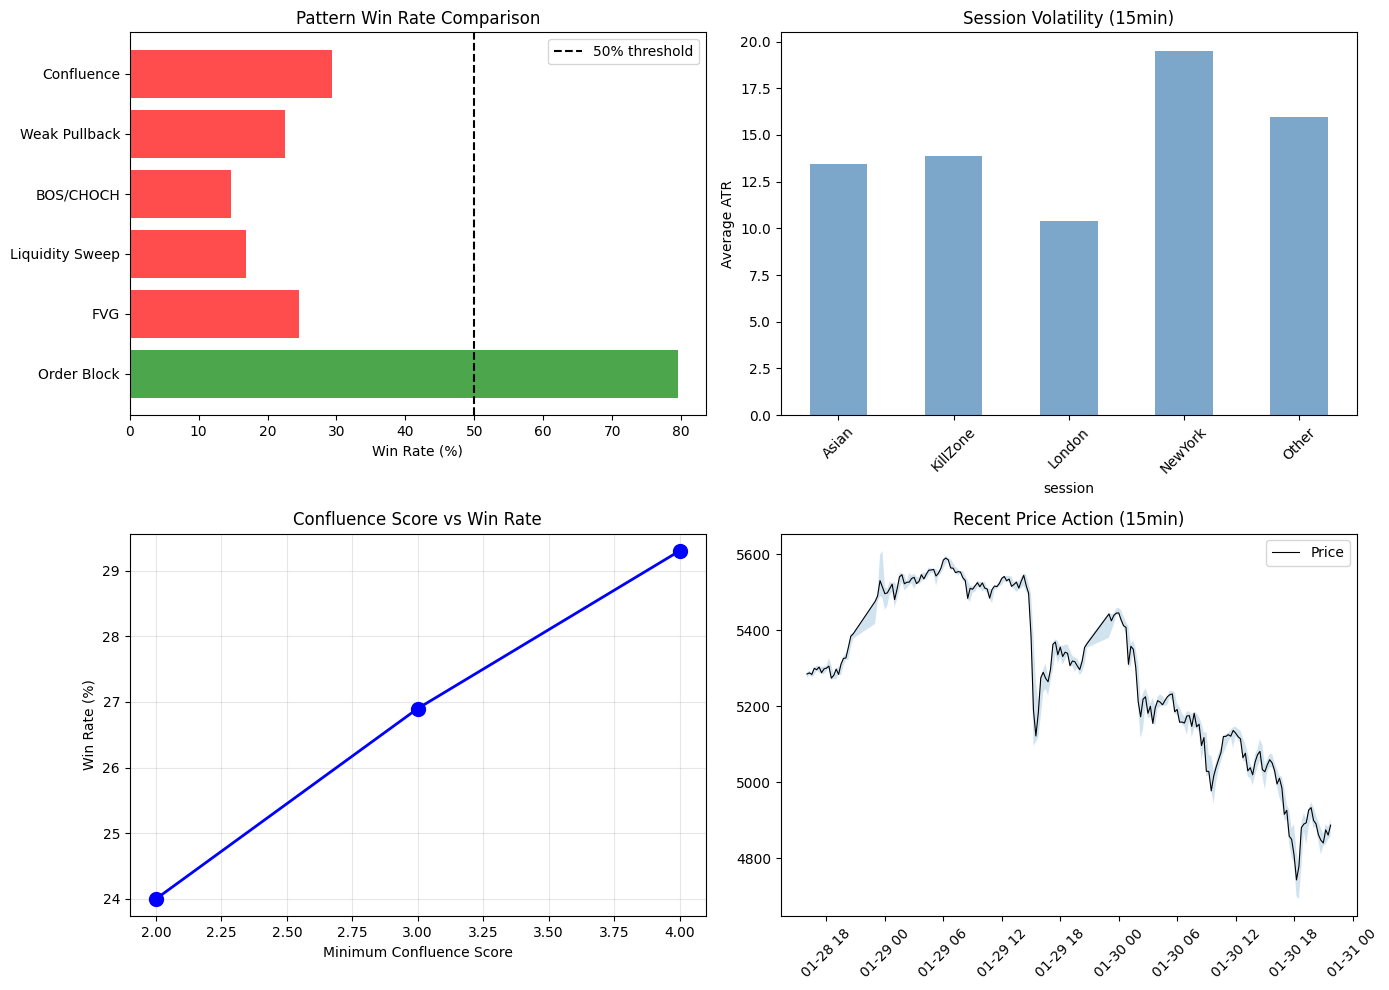


Summary chart saved to: smc_validation_summary.png


In [ ]:
# Cell 27: Final Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Win Rate Comparison
ax1 = axes[0, 0]
if len(summary_df) > 0:
    patterns = summary_df['Pattern'].tolist()
    win_rates = [float(wr.replace('%', '')) for wr in summary_df['Win Rate'].tolist()]
    colors = ['green' if wr >= 50 else 'red' for wr in win_rates]
    ax1.barh(patterns, win_rates, color=colors, alpha=0.7)
    ax1.axvline(x=50, color='black', linestyle='--', label='50% threshold')
    ax1.set_xlabel('Win Rate (%)')
    ax1.set_title('Pattern Win Rate Comparison')
    ax1.legend()

# 2. Session Volatility
ax2 = axes[0, 1]
session_vol = data['15min'].groupby('session')['atr'].mean().dropna()
if len(session_vol) > 0:
    session_vol.plot(kind='bar', ax=ax2, color='steelblue', alpha=0.7)
    ax2.set_ylabel('Average ATR')
    ax2.set_title('Session Volatility (15min)')
    ax2.tick_params(axis='x', rotation=45)

# 3. Confluence Score vs Win Rate
ax3 = axes[1, 0]
if confluence_stats:
    scores = [s['Min Score'] for s in confluence_stats]
    rates = [float(s['Win Rate'].replace('%', '')) for s in confluence_stats]
    ax3.plot(scores, rates, 'bo-', markersize=10, linewidth=2)
    ax3.set_xlabel('Minimum Confluence Score')
    ax3.set_ylabel('Win Rate (%)')
    ax3.set_title('Confluence Score vs Win Rate')
    ax3.grid(True, alpha=0.3)

# 4. Price Chart with Sample Patterns
ax4 = axes[1, 1]
sample = data['15min'].iloc[-200:]
ax4.plot(sample.index, sample['close'], 'k-', linewidth=0.8, label='Price')
ax4.fill_between(sample.index, sample['low'], sample['high'], alpha=0.2)
ax4.set_title('Recent Price Action (15min)')
ax4.tick_params(axis='x', rotation=45)
ax4.legend()

plt.tight_layout()
plt.savefig('smc_validation_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSummary chart saved to: smc_validation_summary.png")

In [ ]:
# Cell 28: Final Recommendation
def generate_recommendation(summary_df, confluence_stats):
    """Generate final recommendation based on results"""
    print("\n" + "="*60)
    print("              STRATEGY VALIDATION REPORT")
    print("="*60)
    
    # Determine if patterns have edge
    patterns_with_edge = []
    patterns_without_edge = []
    
    for _, row in summary_df.iterrows():
        win_rate = float(row['Win Rate'].replace('%', ''))
        if win_rate >= 50 and row['Trades'] >= 10:
            patterns_with_edge.append((row['Pattern'], win_rate))
        else:
            patterns_without_edge.append((row['Pattern'], win_rate))
    
    # Determine optimal confluence
    optimal_confluence = 2
    if confluence_stats:
        best_confluence = max(confluence_stats, 
                             key=lambda x: float(x['Win Rate'].replace('%', '')))
        optimal_confluence = best_confluence['Min Score']
    
    # Print findings
    print("\n[EDGE CONFIRMED]")
    if patterns_with_edge:
        for pattern, wr in patterns_with_edge:
            print(f"  ✓ {pattern}: {wr:.1f}% win rate")
    else:
        print("  No patterns showed consistent edge")
    
    print("\n[NO EDGE / INSUFFICIENT DATA]")
    if patterns_without_edge:
        for pattern, wr in patterns_without_edge:
            print(f"  ✗ {pattern}: {wr:.1f}% win rate")
    
    print(f"\n[OPTIMAL SETTINGS]")
    print(f"  • Recommended confluence threshold: {optimal_confluence}+ factors")
    print(f"  • Best timeframe: 15min (based on pattern clarity)")
    print(f"  • Best session: London-NY Overlap (Kill Zone)")
    
    # Final verdict
    proceed = len(patterns_with_edge) >= 2
    print("\n" + "="*60)
    if proceed:
        print("PROCEED WITH AGENT SYSTEM: YES")
        print("\nRecommended Technical Analyst Focus:")
        for pattern, wr in sorted(patterns_with_edge, key=lambda x: -x[1]):
            print(f"  1. {pattern} ({wr:.1f}% win rate)")
    else:
        print("PROCEED WITH AGENT SYSTEM: CAUTION")
        print("\nInsufficient edge detected. Consider:")
        print("  • More historical data")
        print("  • Different parameter optimization")
        print("  • Additional confirmation filters")
    
    print("="*60)
    
    return proceed

# Generate recommendation
proceed = generate_recommendation(summary_df, confluence_stats)


              STRATEGY VALIDATION REPORT

[EDGE CONFIRMED]
  ✓ Order Block: 79.6% win rate

[NO EDGE / INSUFFICIENT DATA]
  ✗ FVG: 24.5% win rate
  ✗ Liquidity Sweep: 16.9% win rate
  ✗ BOS/CHOCH: 14.7% win rate
  ✗ Weak Pullback: 22.6% win rate
  ✗ Confluence: 29.3% win rate

[OPTIMAL SETTINGS]
  • Recommended confluence threshold: 4+ factors
  • Best timeframe: 15min (based on pattern clarity)
  • Best session: London-NY Overlap (Kill Zone)

PROCEED WITH AGENT SYSTEM: CAUTION

Insufficient edge detected. Consider:
  • More historical data
  • Different parameter optimization
  • Additional confirmation filters


---
## Data Export Options

In [ ]:
# Cell 29: Export Results (Optional)
# Uncomment to export results to CSV

# summary_df.to_csv('smc_validation_summary.csv', index=False)
# print("Summary exported to smc_validation_summary.csv")

# if len(confluence_map) > 0:
#     confluence_map.to_csv('confluence_setups.csv', index=False)
#     print("Confluence setups exported to confluence_setups.csv")

print("\n=== Notebook Complete ===")
print(f"Total 1-min bars analyzed: {len(df_1min):,}")
print(f"Timeframes tested: {list(TIMEFRAMES.keys())}")
print(f"Patterns validated: Order Block, FVG, Liquidity Sweep, BOS/CHOCH, Weak Pullback")


=== Notebook Complete ===
Total 1-min bars analyzed: 30,740
Timeframes tested: ['1min', '5min', '15min', '30min']
Patterns validated: Order Block, FVG, Liquidity Sweep, BOS/CHOCH, Weak Pullback
